# Sinhala Sign Language Alphabet — Video Preprocessing with MediaPipe Hands

This notebook extracts hand landmarks from sign language alphabet videos using **MediaPipe Hands**.

### Pipeline
1. Read each `.MOV` video from `dataset/ssl-alphabet/`
2. Run MediaPipe Hands on every frame to extract 21 hand landmarks (x, y, z)
3. Normalise landmarks relative to the wrist so they are translation-invariant
4. Build a labelled dataset and persist it for downstream model training

In [1]:
#%pip install mediapipe opencv-python numpy pandas scikit-learn matplotlib

import urllib.request
from pathlib import Path

MODEL_URL  = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
MODEL_PATH = Path("hand_landmarker.task")

if not MODEL_PATH.exists():
    print("Downloading hand_landmarker.task …")
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
    print(f"Saved to {MODEL_PATH} ({MODEL_PATH.stat().st_size / 1e6:.1f} MB)")
else:
    print(f"Model already exists at {MODEL_PATH}")

Model already exists at hand_landmarker.task


In [17]:
import os
import sys
import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
import pickle
import warnings

warnings.filterwarnings("ignore")

from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

BaseOptions        = mp_python.BaseOptions
HandLandmarker     = mp_vision.HandLandmarker
HandLandmarkerOpts = mp_vision.HandLandmarkerOptions
VisionRunningMode  = mp_vision.RunningMode

HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),
    (0, 5), (5, 6), (6, 7), (7, 8),
    (5, 9), (9, 10), (10, 11), (11, 12),
    (9, 13), (13, 14), (14, 15), (15, 16),
    (13, 17), (17, 18), (18, 19), (19, 20),
    (0, 17),
]

print(f"MediaPipe version : {mp.__version__}")
print(f"OpenCV version    : {cv2.__version__}")

MediaPipe version : 0.10.10
OpenCV version    : 4.11.0


## 1 — Configuration

In [18]:
from pathlib import Path

DATASET_DIR = Path("../dataset/ssl-alphabet-converted")
OUTPUT_DIR  = Path("../dataset/processed/ssl-alphabet-converted")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_FILE = "hand_landmarker.task"

MAX_NUM_HANDS   = 1
MIN_DETECTION   = 0.5
MIN_TRACKING    = 0.5

NUM_LANDMARKS   = 21
COORDS_PER_LM   = 3

SEQ_LEN = 30
STRIDE  = 5

In [19]:
# Scan multi-video dataset: dataset/ssl-alphabet-mul/<letter>/*.MOV

video_files = []  # list of (path, label)

for letter_dir in sorted(DATASET_DIR.iterdir()):
    if not letter_dir.is_dir():
        continue
    label = letter_dir.name  # folder name is the Sinhala letter
    vids = [
        v for v in sorted(letter_dir.iterdir())
        if v.suffix.upper() in (".MOV", ".MP4", ".AVI")
    ]
    if not vids:
        continue
    for v in vids:
        video_files.append((v, label))

print(f"Found {len(video_files)} videos in {DATASET_DIR}")

label_counts = {}
for _, label in video_files:
    label_counts[label] = label_counts.get(label, 0) + 1

for label, count in sorted(label_counts.items()):
    print(f"  {label} : {count} videos")

Found 147 videos in ..\dataset\ssl-alphabet-converted
  අ : 3 videos
  අං : 1 videos
  ආ : 4 videos
  ඇ : 3 videos
  ඈ : 3 videos
  ඉ : 2 videos
  ඊ : 4 videos
  උ : 3 videos
  ඌ : 3 videos
  එ : 3 videos
  ඒ : 2 videos
  ඔ : 4 videos
  ඕ : 4 videos
  ක් : 4 videos
  ඛි : 3 videos
  ග් : 3 videos
  ඟ : 5 videos
  ච් : 1 videos
  ඡ් : 1 videos
  ජ් : 4 videos
  ට් : 4 videos
  ඨ් : 1 videos
  ඩ් : 3 videos
  ඪ් : 3 videos
  ණ් : 4 videos
  ඬ : 5 videos
  ත් : 3 videos
  ද් : 3 videos
  ධ් : 1 videos
  න් : 4 videos
  ඳ : 5 videos
  ප් : 4 videos
  ඵ් : 3 videos
  බ් : 4 videos
  භ් : 1 videos
  ම් : 4 videos
  ය් : 3 videos
  ර් : 3 videos
  ල් : 4 videos
  ව් : 4 videos
  ශ් : 3 videos
  ෂ් : 3 videos
  ස් : 4 videos
  හ් : 4 videos
  ළ් : 6 videos
  ෆ් : 1 videos


## 2 — Helper Functions

In [11]:
def result_to_flat_landmarks(result):
    """Convert a HandLandmarkerResult to a flat numpy array.

    Returns (flat_array, detected). flat_array has shape
    (MAX_NUM_HANDS * 21 * 3,); undetected hands are zero-padded.
    """
    landmarks = np.zeros(MAX_NUM_HANDS * NUM_LANDMARKS * COORDS_PER_LM, dtype=np.float32)
    detected = bool(result.hand_landmarks)

    if detected:
        for hand_idx, hand_lms in enumerate(result.hand_landmarks):
            if hand_idx >= MAX_NUM_HANDS:
                break
            offset = hand_idx * NUM_LANDMARKS * COORDS_PER_LM
            for lm_idx, lm in enumerate(hand_lms):
                base = offset + lm_idx * COORDS_PER_LM
                landmarks[base]     = lm.x
                landmarks[base + 1] = lm.y
                landmarks[base + 2] = lm.z

    return landmarks, detected


def normalise_landmarks(landmarks_flat):
    """Translate each hand so that the wrist (landmark 0) is at the origin."""
    normed = landmarks_flat.copy()
    for h in range(MAX_NUM_HANDS):
        offset = h * NUM_LANDMARKS * COORDS_PER_LM
        wrist = normed[offset:offset + COORDS_PER_LM].copy()
        if np.any(wrist != 0):
            for lm in range(NUM_LANDMARKS):
                base = offset + lm * COORDS_PER_LM
                normed[base:base + COORDS_PER_LM] -= wrist
    return normed


def draw_hand_landmarks(image, result):
    """Draw hand landmarks and connections on an RGB image using OpenCV."""
    annotated = image.copy()
    h, w, _ = annotated.shape

    for hand_lms in result.hand_landmarks:
        pts = [(int(lm.x * w), int(lm.y * h)) for lm in hand_lms]
        for (i, j) in HAND_CONNECTIONS:
            cv2.line(annotated, pts[i], pts[j], (0, 255, 0), 2)
        for px, py in pts:
            cv2.circle(annotated, (px, py), 4, (255, 0, 0), -1)

    return annotated


def get_video_info(video_path):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return {"fps": None, "frames": None, "width": None, "height": None}
    fps = cap.get(cv2.CAP_PROP_FPS)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    return {"fps": fps, "frames": total, "width": w, "height": h}


# Use the first (video, label) pair for a quick sanity check
sample_video, sample_label = video_files[1]
info_sample = get_video_info(sample_video)
print(f"Sample video info ({sample_label}): {info_sample}")

Sample video info (අ): {'fps': 30.0, 'frames': 112, 'width': 1920, 'height': 1080}


## 3 — Visualise a Sample Frame

(WindowsPath('../dataset/ssl-alphabet-converted/අ/ssl-031684f7.mp4'), 'අ')


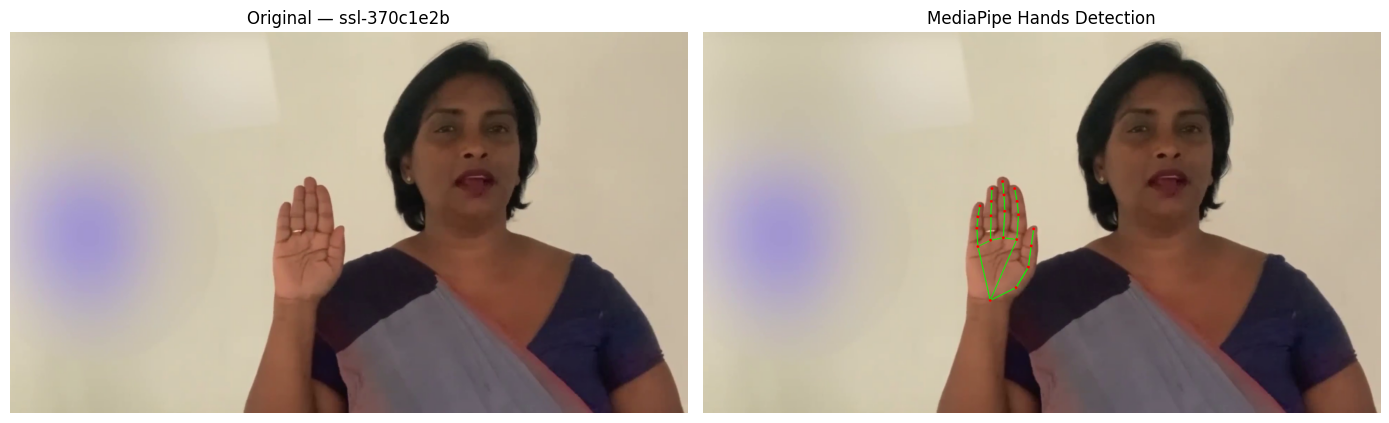

Detected 1 hand(s)


In [20]:
sample_video, sample_label = video_files[1]
print(video_files[0])
cap = cv2.VideoCapture(str(sample_video))

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.set(cv2.CAP_PROP_POS_FRAMES, total_frames // 2)
ret, frame = cap.read()
cap.release()

if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    options = HandLandmarkerOpts(
        base_options=BaseOptions(model_asset_path=MODEL_FILE),
        running_mode=VisionRunningMode.IMAGE,
        num_hands=MAX_NUM_HANDS,
        min_hand_detection_confidence=MIN_DETECTION,
    )
    with HandLandmarker.create_from_options(options) as detector:
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
        result = detector.detect(mp_image)

    annotated = draw_hand_landmarks(frame_rgb, result)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(frame_rgb)
    axes[0].set_title(f"Original — {sample_video.stem}")
    axes[0].axis("off")
    axes[1].imshow(annotated)
    axes[1].set_title("MediaPipe Hands Detection")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

    print(f"Detected {len(result.hand_landmarks)} hand(s)")
else:
    print("Failed to read sample frame.")

## 4 — Extract Landmarks from All Videos (grouped per video)

In [21]:
video_sequences = {}
skipped_frames = defaultdict(int)
processed_frames = defaultdict(int)

options = HandLandmarkerOpts(
    base_options=BaseOptions(model_asset_path=MODEL_FILE),
    running_mode=VisionRunningMode.VIDEO,
    num_hands=MAX_NUM_HANDS,
    min_hand_detection_confidence=MIN_DETECTION,
    min_tracking_confidence=MIN_TRACKING,
)

for vid_path, label in video_files:  # ← unpack here
    cap = cv2.VideoCapture(str(vid_path))

    if not cap.isOpened():
        print(f"  [ERROR] Cannot open {vid_path}")
        continue

    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    frames_for_this_video = []

    with HandLandmarker.create_from_options(options) as detector:
        frame_idx = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
            timestamp_ms = int(frame_idx * 1000 / fps)

            result = detector.detect_for_video(mp_image, timestamp_ms)
            lm_flat, detected = result_to_flat_landmarks(result)

            if detected:
                normed = normalise_landmarks(lm_flat)
                frames_for_this_video.append(normed)
                processed_frames[label] += 1
            else:
                skipped_frames[label] += 1

            frame_idx += 1

    cap.release()

    if frames_for_this_video:
        video_sequences.setdefault(label, []).append(
            np.array(frames_for_this_video, dtype=np.float32)
        )

    total = processed_frames[label] + skipped_frames[label]
    det_rate = processed_frames[label] / total * 100 if total else 0
    print(
        f"  {label} : {processed_frames[label]:>4d} detected / "
        f"{total:>4d} total frames  ({det_rate:.1f}%)"
    )

total_frames = sum(processed_frames.values())
print(f"\nTotal frames with detections: {total_frames}")
print(f"Total videos: {sum(len(v) for v in video_sequences.values())}")
print(f"Unique labels: {len(video_sequences)}")

  අ :   52 detected /  122 total frames  (42.6%)
  අ :  164 detected /  234 total frames  (70.1%)
  අ :  250 detected /  327 total frames  (76.5%)
  අං :   51 detected /   90 total frames  (56.7%)
  ආ :  122 detected /  122 total frames  (100.0%)
  ආ :  183 detected /  224 total frames  (81.7%)
  ආ :  221 detected /  262 total frames  (84.4%)
  ආ :  281 detected /  327 total frames  (85.9%)
  ඇ :   68 detected /   98 total frames  (69.4%)
  ඇ :  127 detected /  157 total frames  (80.9%)
  ඇ :  225 detected /  259 total frames  (86.9%)
  ඈ :   67 detected /  113 total frames  (59.3%)
  ඈ :  148 detected /  235 total frames  (63.0%)
  ඈ :  212 detected /  300 total frames  (70.7%)
  ඉ :   78 detected /  119 total frames  (65.5%)
  ඉ :  161 detected /  233 total frames  (69.1%)
  ඊ :   49 detected /   51 total frames  (96.1%)
  ඊ :  133 detected /  177 total frames  (75.1%)
  ඊ :  180 detected /  225 total frames  (80.0%)
  ඊ :  232 detected /  278 total frames  (83.5%)
  උ :   53 detecte

## 5 — Sliding Window: Build Fixed-Length Sequences

In [22]:
SEQ_LEN = 30
STRIDE  = 5

all_sequences = []
all_labels    = []

for label, videos in video_sequences.items():
    for frames in videos:
        n_frames = len(frames)
        if n_frames < SEQ_LEN:
            padded = np.zeros((SEQ_LEN, frames.shape[1]), dtype=np.float32)
            padded[:n_frames] = frames
            all_sequences.append(padded)
            all_labels.append(label)
        else:
            for start in range(0, n_frames - SEQ_LEN + 1, STRIDE):
                all_sequences.append(frames[start:start + SEQ_LEN])
                all_labels.append(label)

X = np.array(all_sequences, dtype=np.float32)
y = np.array(all_labels)

print(f"Sequence matrix X : {X.shape}  (sequences, timesteps, features)")
print(f"Label array y     : {y.shape}")
print(f"SEQ_LEN={SEQ_LEN}, STRIDE={STRIDE}")
print(f"Features per timestep: {X.shape[2]}  "
      f"({MAX_NUM_HANDS} hands × {NUM_LANDMARKS} landmarks × {COORDS_PER_LM} coords)")

Sequence matrix X : (1226, 30, 63)  (sequences, timesteps, features)
Label array y     : (1226,)
SEQ_LEN=30, STRIDE=5
Features per timestep: 63  (1 hands × 21 landmarks × 3 coords)


## 6 — Sequence Dataset Statistics

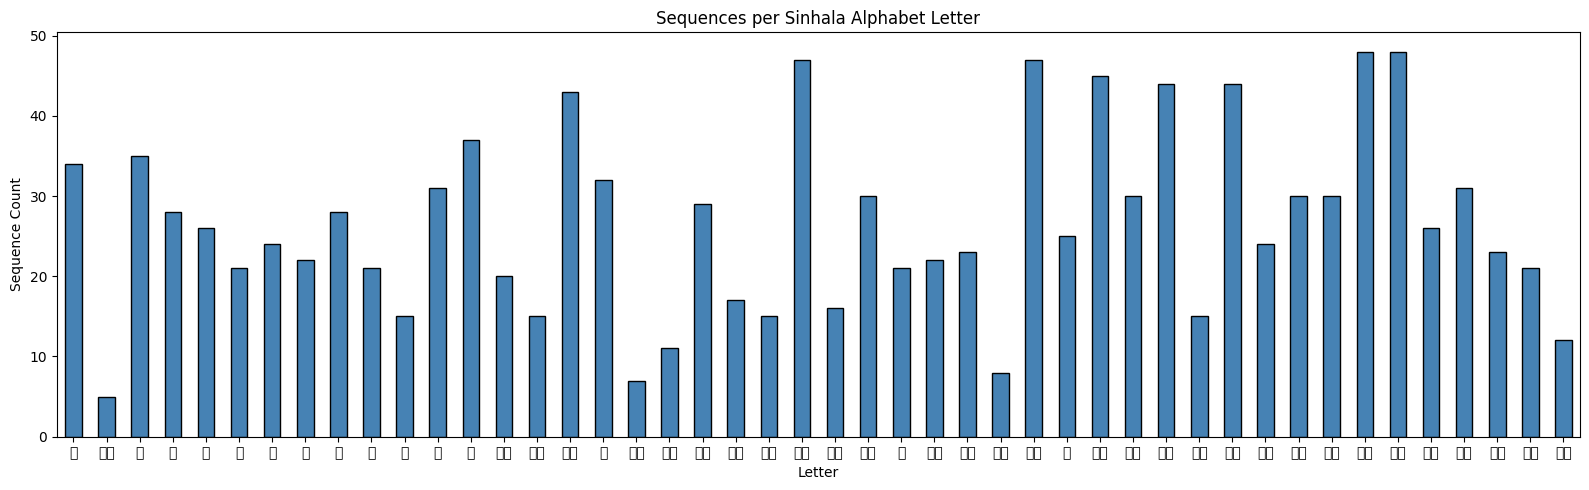


Min samples : 5 (අං)
Max samples : 48 (ව්)
Mean samples: 27


In [23]:
label_series = pd.Series(y, name="label")
counts = label_series.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(16, 5))
counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Sequences per Sinhala Alphabet Letter")
ax.set_xlabel("Letter")
ax.set_ylabel("Sequence Count")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

print(f"\nMin samples : {counts.min()} ({counts.idxmin()})")
print(f"Max samples : {counts.max()} ({counts.idxmax()})")
print(f"Mean samples: {counts.mean():.0f}")

## 7 — Encode Labels

In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Label mapping:")
for idx, cls in enumerate(le.classes_):
    print(f"  {idx:>2d} → {cls}")

num_classes = len(le.classes_)
print(f"\nTotal classes: {num_classes}")

Label mapping:
   0 → අ
   1 → අං
   2 → ආ
   3 → ඇ
   4 → ඈ
   5 → ඉ
   6 → ඊ
   7 → උ
   8 → ඌ
   9 → එ
  10 → ඒ
  11 → ඔ
  12 → ඕ
  13 → ක්
  14 → ඛි
  15 → ග්
  16 → ඟ
  17 → ච්
  18 → ඡ්
  19 → ජ්
  20 → ට්
  21 → ඨ්
  22 → ඩ්
  23 → ඪ්
  24 → ණ්
  25 → ඬ
  26 → ත්
  27 → ද්
  28 → ධ්
  29 → න්
  30 → ඳ
  31 → ප්
  32 → ඵ්
  33 → බ්
  34 → භ්
  35 → ම්
  36 → ය්
  37 → ර්
  38 → ල්
  39 → ව්
  40 → ශ්
  41 → ෂ්
  42 → ස්
  43 → හ්
  44 → ළ්
  45 → ෆ්

Total classes: 46


## 8 — Train / Validation / Test Split

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

min_class_count = np.bincount(y_temp.astype(int)).min()
use_stratify = min_class_count >= 2

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42,
    stratify=y_temp if use_stratify else None
)

if not use_stratify:
    print("⚠ Some classes had < 2 samples in temp set; val/test split is NOT stratified.")

print(f"Train : {X_train.shape[0]:>6d} samples")
print(f"Val   : {X_val.shape[0]:>6d} samples")
print(f"Test  : {X_test.shape[0]:>6d} samples")

⚠ Some classes had < 2 samples in temp set; val/test split is NOT stratified.
Train :    858 samples
Val   :    184 samples
Test  :    184 samples


## 9 — Save Preprocessed Data

In [26]:
dataset_dict = {
    "X_train": X_train,
    "X_val": X_val,
    "X_test": X_test,
    "y_train": y_train,
    "y_val": y_val,
    "y_test": y_test,
    "label_encoder": le,
    "num_classes": num_classes,
    "max_num_hands": MAX_NUM_HANDS,
    "num_landmarks": NUM_LANDMARKS,
    "coords_per_landmark": COORDS_PER_LM,
    "seq_len": SEQ_LEN,
    "stride": STRIDE,
}

output_path = OUTPUT_DIR / "ssl_alphabet_sequences.pkl"
with open(output_path, "wb") as f:
    pickle.dump(dataset_dict, f)

size_mb = output_path.stat().st_size / (1024 * 1024)
print(f"Saved sequence dataset to {output_path}")
print(f"File size: {size_mb:.2f} MB")

Saved sequence dataset to ..\dataset\processed\ssl-alphabet-converted\ssl_alphabet_sequences.pkl
File size: 8.85 MB


In [27]:
with open(output_path, "rb") as f:
    loaded = pickle.load(f)

print("Reloaded successfully.")
print(f"  X_train shape : {loaded['X_train'].shape}  (sequences, timesteps, features)")
print(f"  y_train shape : {loaded['y_train'].shape}")
print(f"  SEQ_LEN       : {loaded['seq_len']}")
print(f"  STRIDE        : {loaded['stride']}")
print(f"  Classes       : {list(loaded['label_encoder'].classes_)}")

Reloaded successfully.
  X_train shape : (858, 30, 63)  (sequences, timesteps, features)
  y_train shape : (858,)
  SEQ_LEN       : 30
  STRIDE        : 5
  Classes       : ['අ', 'අං', 'ආ', 'ඇ', 'ඈ', 'ඉ', 'ඊ', 'උ', 'ඌ', 'එ', 'ඒ', 'ඔ', 'ඕ', 'ක්', 'ඛි', 'ග්', 'ඟ', 'ච්', 'ඡ්', 'ජ්', 'ට්', 'ඨ්', 'ඩ්', 'ඪ්', 'ණ්', 'ඬ', 'ත්', 'ද්', 'ධ්', 'න්', 'ඳ', 'ප්', 'ඵ්', 'බ්', 'භ්', 'ම්', 'ය්', 'ර්', 'ල්', 'ව්', 'ශ්', 'ෂ්', 'ස්', 'හ්', 'ළ්', 'ෆ්']


In [8]:
# Detect videos that show 2 hands in at least one sampled frame

from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
import mediapipe as mp
import cv2

BaseOptions        = mp_python.BaseOptions
HandLandmarker     = mp_vision.HandLandmarker
HandLandmarkerOpts = mp_vision.HandLandmarkerOptions
VisionRunningMode  = mp_vision.RunningMode

two_hand_videos = []

options = HandLandmarkerOpts(
    base_options=BaseOptions(model_asset_path=MODEL_FILE),
    running_mode=VisionRunningMode.IMAGE,
    num_hands=MAX_NUM_HANDS,
    min_hand_detection_confidence=MIN_DETECTION,
)

with HandLandmarker.create_from_options(options) as detector:
    for vid_path, label in video_files:
        cap = cv2.VideoCapture(str(vid_path))
        if not cap.isOpened():
            print(f"[WARN] Cannot open {vid_path}")
            continue

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total_frames <= 0:
            cap.release()
            continue

        # Sample a few frames across the video
        sample_idxs = sorted(set([
            total_frames // 4,
            total_frames // 2,
            (3 * total_frames) // 4,
        ]))

        found_two = False
        for idx in sample_idxs:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if not ret:
                continue

            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
            result = detector.detect(mp_image)

            if len(result.hand_landmarks) >= 2:
                found_two = True
                break

        cap.release()

        if found_two:
            two_hand_videos.append((label, vid_path.name))

print("\nVideos with at least one frame containing 2 hands:")
for label, name in two_hand_videos:
    print(f"  {label} / {name}")

[WARN] Cannot open ..\dataset\ssl-alphabet\ඒ\2.mp4

Videos with at least one frame containing 2 hands:
